# Tutorial

This is a tutorial demonstrating the basics of the Python package `statmechcrack`.

## Model Creation

The crack model is imported from the package as the `Crack` class,

In [1]:
from statmechcrack import Crack

Instantiating the class creates a particular model instance,

In [2]:
model = Crack()

Keyword arguments allow model features to be selected during instantiation, such as choosing 8 repeat units behind the crack tip and a nondimensional energy scale of 88 ahead of the crack tip:

In [3]:
model = Crack(N=8, varepsilon=88)

## Model Methods

A crack model instance has many methods available, such as `v`, the nondimensional end separation as a function of the nondimensional end force

In [4]:
model.v

<bound method Crack.v of <statmechcrack.core.Crack object at 0x7ff2ac545610>>

In [5]:
model.v(1)

array([4.28297647])

An array of nondimensional forces can be input, and the results plotted:

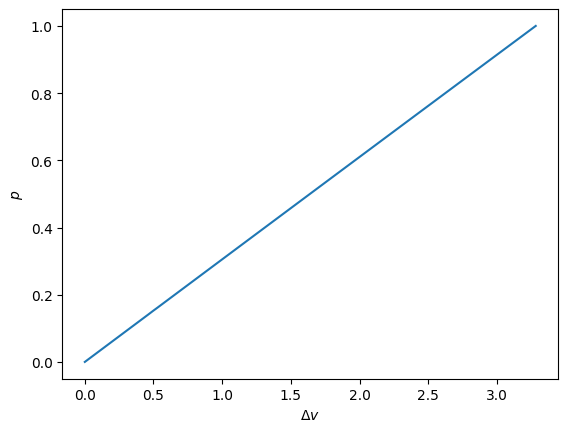

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from statmechcrack import Crack
model = Crack(N=8, varepsilon=88)
p = np.linspace(0, 1, 100)
plt.plot(model.v(p) - 1, p)
plt.xlabel(r'$\Delta v$')
plt.ylabel(r'$p$')
plt.show()

## Thermodynamic Ensembles

Generally, results will differ when either a constant end force or a constant end separation is applied to the crack model system. These are the isotensional and isometric thermodynamic ensembles, respectively. The ``ensemble`` can be specified when computing a result using a class method. For example, the nondimensional end force under a nondimensional end separation of 3 (isometric) is not exactly the same force that will cause a nondimensional end separation of 3 in the isotensional ensemble:"

In [7]:
model.p(3, ensemble='isometric')

array([0.60998242])

In [8]:
model.v(0.60998242, ensemble='isotensional')

array([3.00010209])

## Thermodynamic Limit

As the model system becomes large (many repeat units), the results from any ensemble tend to converge. This is referred to as the thermodynamic limit.

In [9]:
model = Crack(N=25, M=25, varepsilon=88)
model.p(3, ensemble='isometric')

array([0.03067685])

In [10]:
model.v(0.03067685, ensemble='isotensional')

array([2.99999971])

## Calculations Approaches

The coupling between degrees of freedom in this model system prevents thermodynamic functions (the class methods) from being evaluated analytically. Two calculation approaches are provided: an analytic, asymptotically-valid approximation approach, and a Monte Carlo approach. The asymptotic `approach` is the default. As the bonds ahead of the crack tip become stiff, the asymptotic approach becomes valid:

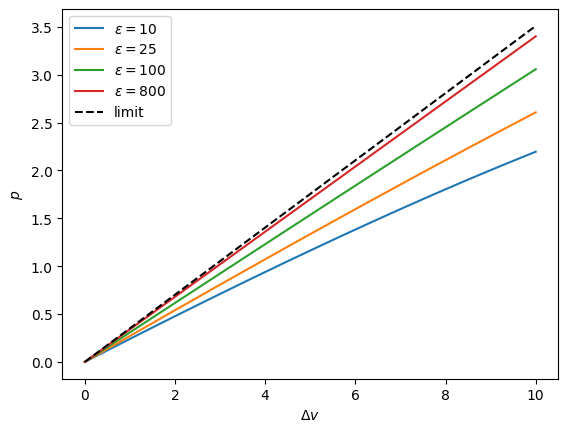

In [11]:
v = np.linspace(1, 11, 33)
_ = plt.figure()
for varepsilon in [10, 25, 100, 800]:
    model = Crack(varepsilon=varepsilon)
    p = model.p(v, approach='asymptotic')
    _ = plt.plot(v - 1, p, label=r'$\varepsilon=$'+str(varepsilon))
p_0 = model.p_0_isometric(v, [1, 1])
_ = plt.plot(v - 1, p_0, 'k--', label='limit')
_ = plt.xlabel(r'$\Delta v$')
_ = plt.ylabel(r'$p$')
_ = plt.legend()
plt.show()

The infinitely-stiff limit is given by the reference system, which is where the bonds ahead of the crack tip are rigidly constrained, and which is analytically solvable in this case.